In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [6]:
sec_path = "/Users/apple/PROJECT/hons_project/data/SP500/nvidia/SEC/dtm_0001045810_2.parquet"

sec_df = pd.read_parquet(sec_path)
sec_df = sec_df.dropna()
sec_df = sec_df.iloc[:, :6]
new_columns = list(sec_df.columns)
new_columns[2:6] = ['sec_vol', 'sec_ret', 'sec_vol+1','sec_ret+1']
coulmns_to_drop = ['_cik']
sec_df.columns = new_columns
sec_df = sec_df.drop(columns=coulmns_to_drop)
print(sec_df.shape)
print(sec_df.columns)
print(sec_df.head())

(68, 5)
Index(['Date', 'sec_vol', 'sec_ret', 'sec_vol+1', 'sec_ret+1'], dtype='object')
         Date   sec_vol   sec_ret  sec_vol+1  sec_ret+1
0  2006-03-16  0.000388 -0.028300   0.000336  -0.012795
1  2007-03-16  0.000400 -0.010177   0.000133   0.000352
2  2009-03-13  0.010890  0.009226   0.001266   0.049700
3  2010-03-18  0.000552 -0.049756   0.000653   0.026882
4  2011-03-16  0.000975  0.006834   0.000801   0.007808


In [7]:
calls_path = "/Users/apple/PROJECT/hons_project/data/SP500/nvidia/calls/dtm_0001045810_2.parquet"

call_df = pd.read_parquet(calls_path)
call_df = call_df.dropna()
call_df = call_df.iloc[:, :6]
new_columns = list(call_df.columns)
new_columns[2:6] = ['calls_vol', 'calls_ret', 'calls_vol+1','calls_ret+1']
coulmns_to_drop = ['_cik']
call_df.columns = new_columns
call_df = call_df.drop(columns=coulmns_to_drop)
print(call_df.shape)
print(call_df.columns)
print(call_df.head())

(73, 5)
Index(['Date', 'calls_vol', 'calls_ret', 'calls_vol+1', 'calls_ret+1'], dtype='object')
         Date  calls_vol  calls_ret  calls_vol+1  calls_ret+1
0  2006-01-30   0.000214  -0.031934     0.000230    -0.011939
1  2006-05-11   0.000772  -0.124471     0.002405    -0.053969
2  2006-08-10   0.000651  -0.027815     0.001921     0.043676
3  2006-11-09   0.000363  -0.024948     0.000772    -0.015844
4  2007-02-13   0.000879  -0.004730     0.000331    -0.022108


In [8]:
report_path = "/Users/apple/PROJECT/hons_project/data/SP500/nvidia/reports/dtm_0001045810_2.parquet"

report_df = pd.read_parquet(report_path)
report_df = report_df.dropna()
report_df = report_df.iloc[:, :6]
new_columns = list(report_df.columns)
new_columns[2:6] = ['report_vol', 'report_ret', 'report_vol+1','report_ret+1']
coulmns_to_drop = ['_cik']
report_df.columns = new_columns
report_df = report_df.drop(columns=coulmns_to_drop)
print(report_df.shape)
print(report_df.columns)
print(report_df.head())

(913, 5)
Index(['Date', 'report_vol', 'report_ret', 'report_vol+1', 'report_ret+1'], dtype='object')
         Date  report_vol  report_ret  report_vol+1  report_ret+1
0  2006-01-26    0.000291    0.037900      0.000228     -0.005855
1  2006-01-30    0.000214   -0.031934      0.000230      0.011939
2  2006-03-31    0.000573   -0.002963      0.000374     -0.005889
3  2006-05-12    0.001416   -0.053969      0.000407     -0.016231
4  2006-08-11    0.001085    0.043676      0.000396      0.017458


In [9]:
# How to open json file?
import json
json_path = "/Users/apple/PROJECT/data/SP500-historical-prices_2012-2024/NVDA.json"
with open(json_path, 'r') as f:
    json_data = json.load(f)
data = json_data['data']

# Extract relevant fields and convert to DataFrame
price_df = pd.DataFrame([{
    'Date': item['attributes']['as_of_date'],
    'open': item['attributes']['open'],
    'close': item['attributes']['close'],
    'high': item['attributes']['high'],
    'low': item['attributes']['low'],
    'volume': item['attributes']['volume'],
    'div_adj_factor': item['attributes']['div_adj_factor']
} for item in data])

# Display the DataFrame
print(price_df.head())
print(price_df.shape)

         Date     open     close     high       low       volume  \
0  2012-09-13  0.34275  0.341875  0.34400  0.335500  433981680.0   
1  2012-09-14  0.34175  0.346000  0.35200  0.341750  339467840.0   
2  2012-09-17  0.34675  0.336500  0.34675  0.332750  493362440.0   
3  2012-09-18  0.33275  0.338750  0.34275  0.332375  360006840.0   
4  2012-09-19  0.33950  0.342750  0.34750  0.335500  451975880.0   

   div_adj_factor  
0        0.917186  
1        0.917185  
2        0.917186  
3        0.917187  
4        0.917185  
(3010, 7)


In [10]:
# Ensure all Date columns are of the same type
price_df['Date'] = pd.to_datetime(price_df['Date'])
sec_df['Date'] = pd.to_datetime(sec_df['Date'])
call_df['Date'] = pd.to_datetime(call_df['Date'])
report_df['Date'] = pd.to_datetime(report_df['Date'])
# Merge the datasets on the 'Date' column
merged_df = price_df.copy()  # Start with the 4th dataset as the base
merged_df = pd.merge(merged_df, sec_df, on='Date', how='left')  # Merge with the 1st dataset
merged_df = pd.merge(merged_df, call_df, on='Date', how='left')  # Merge with the 2nd dataset
merged_df = pd.merge(merged_df, report_df, on='Date', how='left')  # Merge with the 3rd dataset

# Add Return column
merged_df['return'] = merged_df['close'].pct_change()
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
# Display the merged DataFrame
print(merged_df.head(1000))
print(merged_df.shape)


          Date     open     close     high       low       volume  \
0   2012-09-13  0.34275  0.341875  0.34400  0.335500  433981680.0   
1   2012-09-14  0.34175  0.346000  0.35200  0.341750  339467840.0   
2   2012-09-17  0.34675  0.336500  0.34675  0.332750  493362440.0   
3   2012-09-18  0.33275  0.338750  0.34275  0.332375  360006840.0   
4   2012-09-19  0.33950  0.342750  0.34750  0.335500  451975880.0   
..         ...      ...       ...      ...       ...          ...   
995 2016-07-21  1.35250  1.330500  1.35675  1.326000  361307880.0   
996 2016-07-22  1.33525  1.366750  1.36675  1.325500  315766600.0   
997 2016-07-25  1.37500  1.392000  1.39525  1.369000  312528440.0   
998 2016-07-26  1.40425  1.415750  1.42300  1.402250  514509560.0   
999 2016-07-27  1.42800  1.401500  1.43050  1.393000  446675440.0   

     div_adj_factor  sec_vol  sec_ret  sec_vol+1  sec_ret+1  calls_vol  \
0          0.917186      NaN      NaN        NaN        NaN        NaN   
1          0.917185    

In [11]:
# Data Cleaning: Fill missing values using historical data / Data Imputation

# Identify columns related to vol and ret
columns_to_fill = [col for col in merged_df.columns if 'vol' in col or 'ret' in col]
columns_to_fill = columns_to_fill[1:-1]
# Fill missing values with the most recent (historical) value
merged_df[columns_to_fill] = merged_df[columns_to_fill].fillna(method='ffill')


/var/folders/ls/rcj43y9j0d38d39d28pbbfz40000gn/T/ipykernel_70330/1663994431.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df[columns_to_fill] = merged_df[columns_to_fill].fillna(method='ffill')


In [12]:
# Save the merged DataFrame to a CSV file
output_path = "/Users/apple/PROJECT/hons_project/data/SP500/nvidia/prediction/merged_data.csv"
merged_df.to_csv(output_path, index=False)

print(f"Merged DataFrame saved to {output_path}")

Merged DataFrame saved to /Users/apple/PROJECT/hons_project/data/SP500/nvidia/prediction/merged_data.csv


In [13]:
merged_df.columns

Index(['Date', 'open', 'close', 'high', 'low', 'volume', 'div_adj_factor',
       'sec_vol', 'sec_ret', 'sec_vol+1', 'sec_ret+1', 'calls_vol',
       'calls_ret', 'calls_vol+1', 'calls_ret+1', 'report_vol', 'report_ret',
       'report_vol+1', 'report_ret+1', 'return'],
      dtype='object')

# Time-Series Analysis and EDA

In [14]:
merged_df_path = "/Users/apple/PROJECT/hons_project/data/SP500/nvidia/prediction/merged_data.csv"
merged_df = pd.read_csv(merged_df_path)
print(merged_df.head())
print(merged_df.shape)

         Date     open     close     high       low       volume  \
0  2012-09-13  0.34275  0.341875  0.34400  0.335500  433981680.0   
1  2012-09-14  0.34175  0.346000  0.35200  0.341750  339467840.0   
2  2012-09-17  0.34675  0.336500  0.34675  0.332750  493362440.0   
3  2012-09-18  0.33275  0.338750  0.34275  0.332375  360006840.0   
4  2012-09-19  0.33950  0.342750  0.34750  0.335500  451975880.0   

   div_adj_factor  sec_vol  sec_ret  sec_vol+1  sec_ret+1  calls_vol  \
0        0.917186      NaN      NaN        NaN        NaN        NaN   
1        0.917185      NaN      NaN        NaN        NaN        NaN   
2        0.917186      NaN      NaN        NaN        NaN        NaN   
3        0.917187      NaN      NaN        NaN        NaN        NaN   
4        0.917185      NaN      NaN        NaN        NaN        NaN   

   calls_ret  calls_vol+1  calls_ret+1  report_vol  report_ret  report_vol+1  \
0        NaN          NaN          NaN         NaN         NaN           NaN  

In [ ]:

columns_to_check = ['sec_vol', 'sec_ret', 'calls_vol', 'calls_ret', 'return']
merged_df = merged_df.dropna(subset=columns_to_check + ['return']).reset_index(drop=True)

print(merged_df.shape)
print(merged_df.head())

(3246, 20)
         Date       open      close       high        low        volume  \
0  2013-01-24  16.428571  16.089286  16.633214  16.080357  1.460852e+09   
1  2013-01-25  16.131786  15.710000  16.293929  15.535714  1.207974e+09   
2  2013-01-28  15.636607  16.065357  16.186071  15.566429  7.855157e+08   
3  2013-01-29  16.375000  16.366786  16.435714  16.147143  5.710721e+08   
4  2013-01-30  16.321429  16.315357  16.521429  16.232143  4.171533e+08   

   div_adj_factor   sec_vol   sec_ret  sec_vol+1  sec_ret+1  calls_vol  \
0        0.851038  0.000246 -0.044724   0.000819   0.026494   0.000125   
1        0.851038  0.000246 -0.044724   0.000819   0.026494   0.000125   
2        0.851038  0.000246 -0.044724   0.000819   0.026494   0.000125   
3        0.851038  0.000246 -0.044724   0.000819   0.026494   0.000125   
4        0.851038  0.000246 -0.044724   0.000819   0.026494   0.000125   

   calls_ret  calls_vol+1  calls_ret+1  report_vol  report_ret  report_vol+1  \
0  -0.145573 

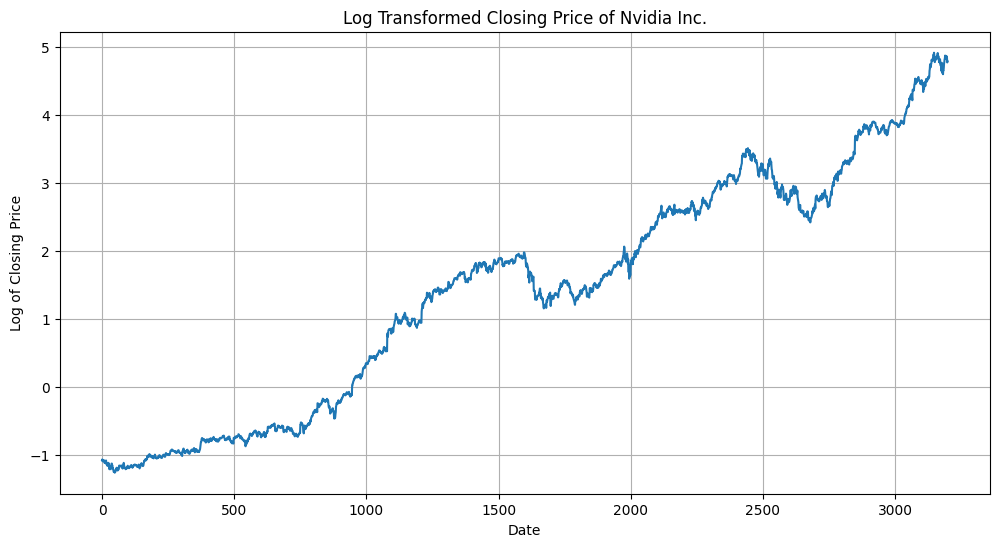

In [16]:
# Transformations: Apply natural logarithm to 'close' column


# Apply log transformation
df_log = np.log(merged_df['close'])

# Plot the transformed data
plt.figure(figsize=(12,6))
plt.plot(df_log)
plt.title('Log Transformed Closing Price of Nvidia Inc.')
plt.xlabel('Date')
plt.ylabel('Log of Closing Price')
plt.grid(True)
plt.show()

In [17]:
price_df = merged_df['close']
price_df.describe()

count    3199.000000
mean       13.812497
std        23.131425
min         0.284500
25%         0.653000
50%         4.802500
75%        15.677000
max       135.580000
Name: close, dtype: float64

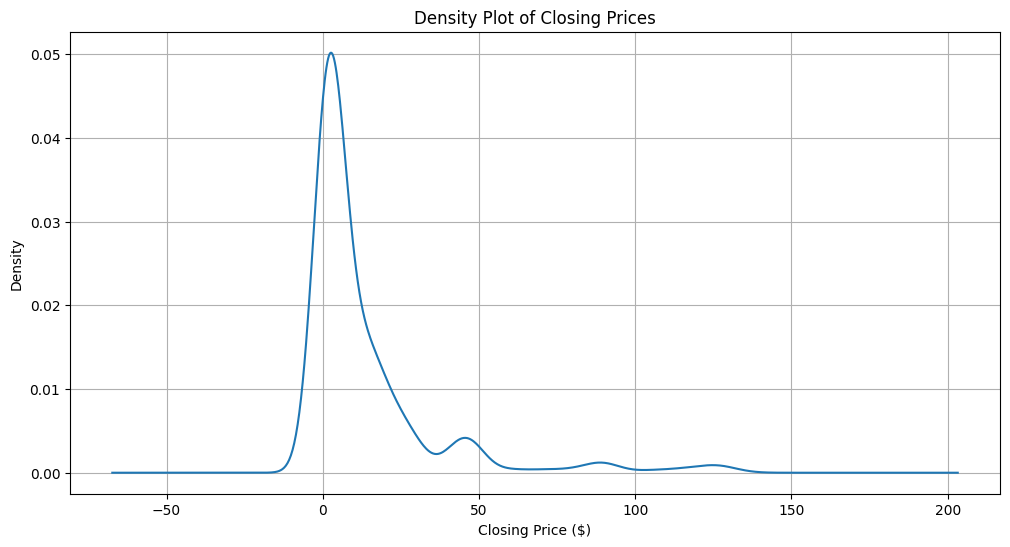

In [18]:
# Density plot
plt.figure(figsize=(12,6))
price_df.plot(kind='kde')
plt.title('Density Plot of Closing Prices')
plt.xlabel('Closing Price ($)')
plt.grid(True)
plt.show()


### Interpretation for this plot and key takeaways
This KDE shows price clustering across regimes, a hallmark of non-stationary financial time series.

AAPL’s price distribution is not normal, but multi-modal and regime-shifted — meaning models assuming stationary Gaussian distributions would fail.

For risk modeling or forecasting, one would consider mixture distributions (e.g., Gaussian Mixture Models) or regime-switching models (e.g., Hidden Markov Models) to capture this structure.

In [19]:
# Decomposing Time Series
# Decompose the time series to observe trend and seasonality.

from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
result = seasonal_decompose(df_log, model='multiplicative', period=252)  # Approximate trading days in a year

# Plot decomposition
result.plot()
plt.show()

ValueError: Multiplicative seasonality is not appropriate for zero and negative values

### Stationarity Testing

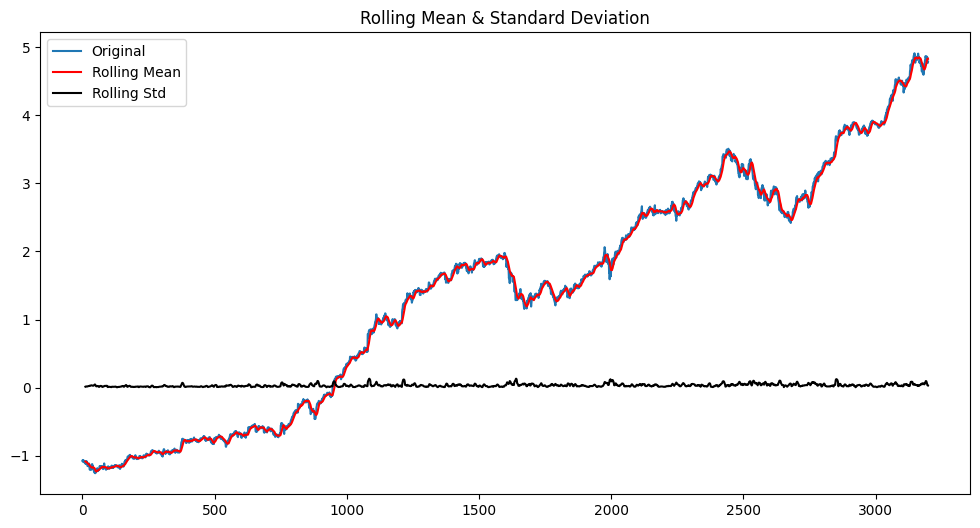

Results of Augmented Dickey-Fuller Test:
Test Statistic                    0.460516
p-value                           0.983622
#Lags Used                        9.000000
Number of Observations Used    3189.000000
Critical Value (1%)              -3.432402
Critical Value (5%)              -2.862447
Critical Value (10%)             -2.567253
dtype: float64


In [20]:
# Understanding Stationarity
# A stationary time series has constant mean and variance over time. Most time series models assume stationarity.

# Augmented Dickey-Fuller Test
# Use the ADF test to check for stationarity.

from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    # Rolling statistics
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()

    # Plot rolling statistics
    plt.figure(figsize=(12,6))
    plt.plot(timeseries, label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label='Rolling Std')
    plt.legend()
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

    # Perform ADF test
    print('Results of Augmented Dickey-Fuller Test:')
    adf_test = adfuller(timeseries, autolag='AIC')
    adf_output = pd.Series(adf_test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in adf_test[4].items():
        adf_output['Critical Value (%s)' % key] = value
    print(adf_output)

# Test stationarity
test_stationarity(df_log)



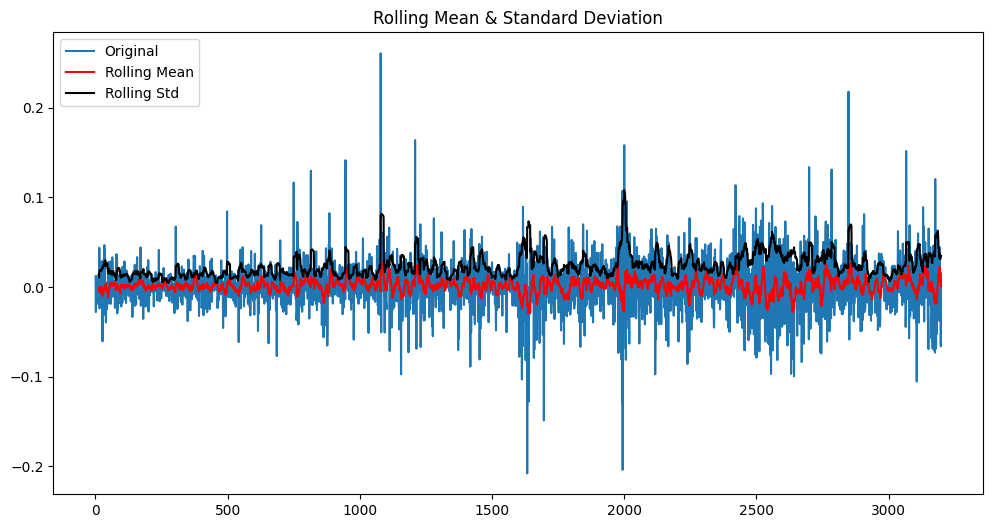

Results of Augmented Dickey-Fuller Test:
Test Statistic                -1.816041e+01
p-value                        2.462200e-30
#Lags Used                     8.000000e+00
Number of Observations Used    3.189000e+03
Critical Value (1%)           -3.432402e+00
Critical Value (5%)           -2.862447e+00
Critical Value (10%)          -2.567253e+00
dtype: float64


In [21]:
# Differencing to Achieve Stationarity
# If the series is non-stationary, apply differencing.

# Differencing
df_log_diff = df_log.diff().dropna()

# Test stationarity again
test_stationarity(df_log_diff)


### Determining ARIMA Parameters

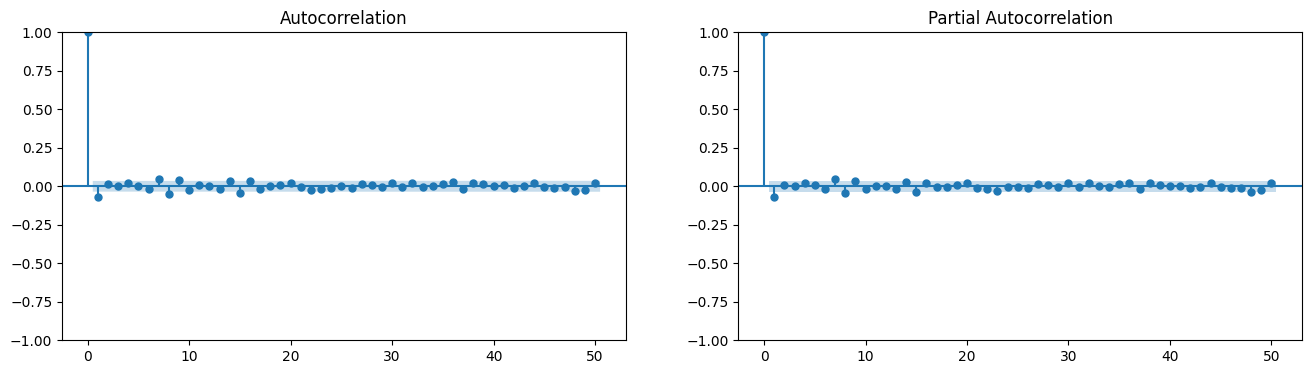

In [22]:
# Autocorrelation and Partial Autocorrelation Plots
# Plot ACF and PACF to identify potential values of p and q.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(16,4))
plot_acf(df_log_diff, lags=50, ax=axes[0])
plot_pacf(df_log_diff, lags=50, ax=axes[1])
plt.show()



/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-13942.757, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-13931.593, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-13944.537, Time=0.11 sec


/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-13944.217, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-13919.329, Time=0.12 sec


/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-13942.759, Time=0.21 sec


/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-13940.823, Time=0.58 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-13930.269, Time=0.06 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 1.522 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3199
Model:               SARIMAX(1, 1, 0)   Log Likelihood                6975.269
Date:                Mon, 01 Sep 2025   AIC                         -13944.537
Time:                        17:01:06   BIC                         -13926.327
Sample:                             0   HQIC                        -13938.008
                               - 3199                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


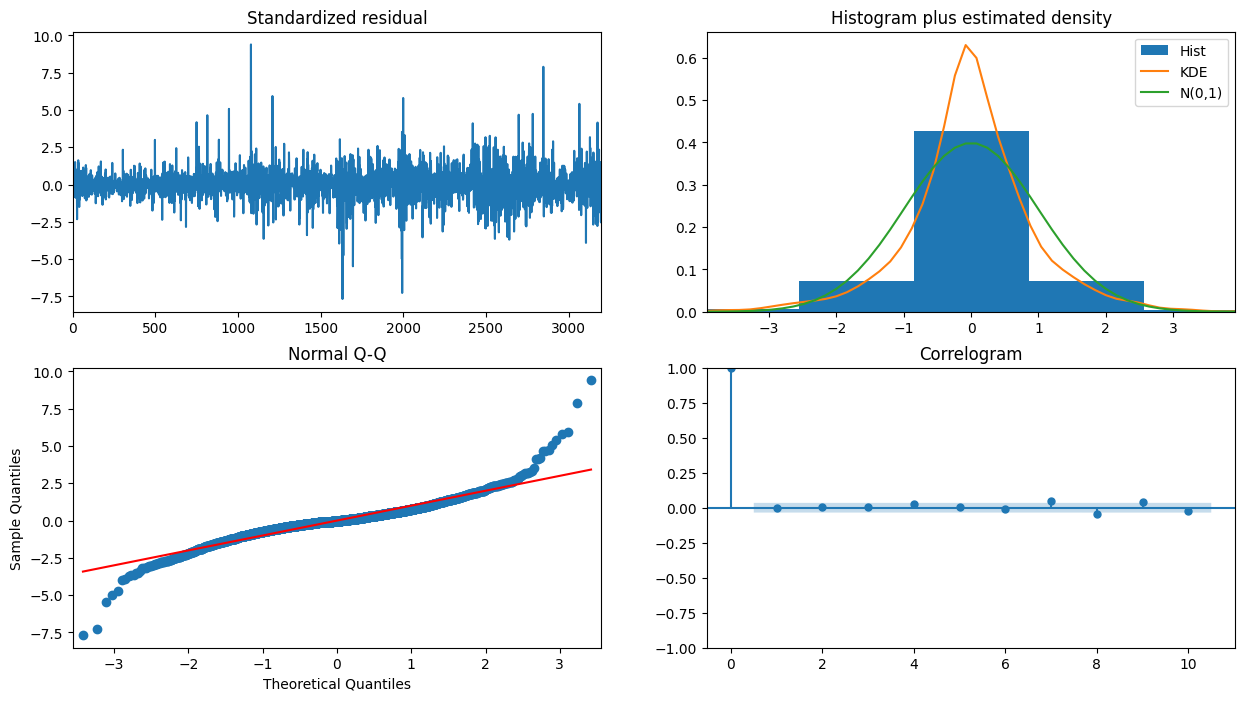

In [23]:
# Using Auto ARIMA to Find Optimal Parameters

import pmdarima as pm

# Auto ARIMA
model_autoARIMA = pm.auto_arima(df_log, start_p=1, start_q=1,
                                test='adf',       # use adf test to find optimal 'd'
                                max_p=5, max_q=5, # maximum p and q
                                m=1,              # frequency of series
                                d=None,           # let model determine 'd'
                                seasonal=False,   # No Seasonality
                                start_P=0, 
                                D=0, 
                                trace=True,
                                error_action='ignore',  
                                suppress_warnings=True, 
                                stepwise=True)

print(model_autoARIMA.summary())

# Plot diagnostics
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()


Target Value Over Time

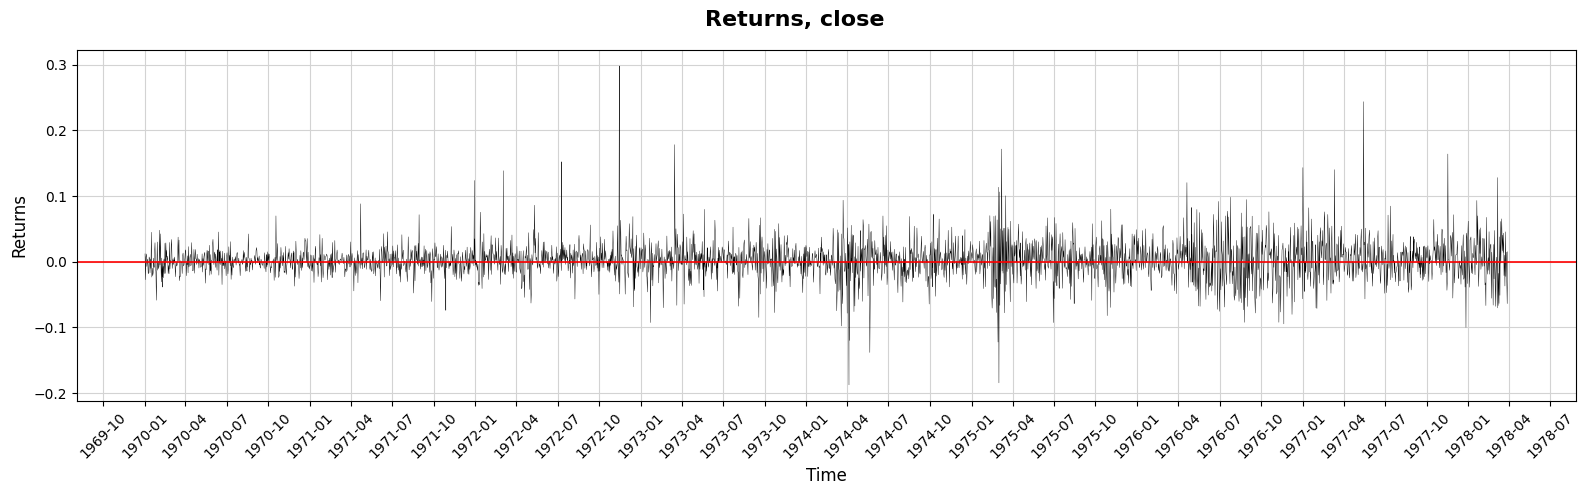

In [24]:
import matplotlib.dates as mdates


gridColor = 'lightgrey'

xx= merged_df['Date']
# xx = pd.to_datetime(merged_df['Date'])  # Ensure Date is in datetime format
yy= merged_df['return']

plt.figure(figsize=(16, 5))
plt.plot(xx,yy, color = 'black', linewidth =0.3)
plt.suptitle('Returns, close', weight='bold', fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Returns", fontsize=12)

# Format the x-axis to show years and months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as Year-Month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every 3rd month


plt.grid(color = gridColor , linewidth=0.8)
plt.axhline(0, color='red', linestyle='-', linewidth=1.2)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

The cumulative values of return over time

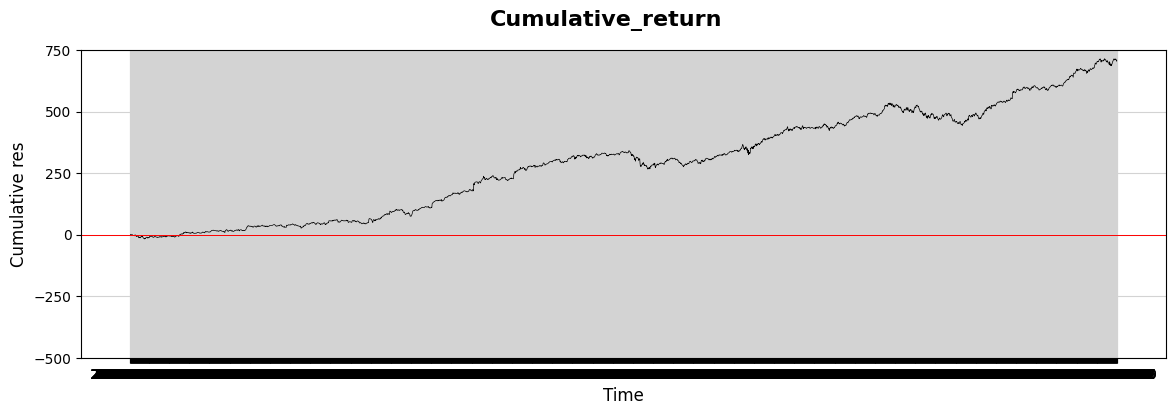

In [25]:
plt.figure(figsize=(14, 4))
plt.plot(xx,yy.cumsum()*100, color = 'black', linewidth =0.5)
plt.suptitle('Cumulative_return', weight='bold', fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Cumulative res", fontsize=12)
plt.yticks(np.arange(-500,1000,250))
#plt.xticks(np.arange(0,170,10))
plt.grid(color = gridColor)
#plt.grid(color = 'lightblue')
plt.axhline(0, color='red', linestyle='-', linewidth=0.7)
plt.show()

#### True Distribution of APPL via Keneral Density Estimation (KDE)

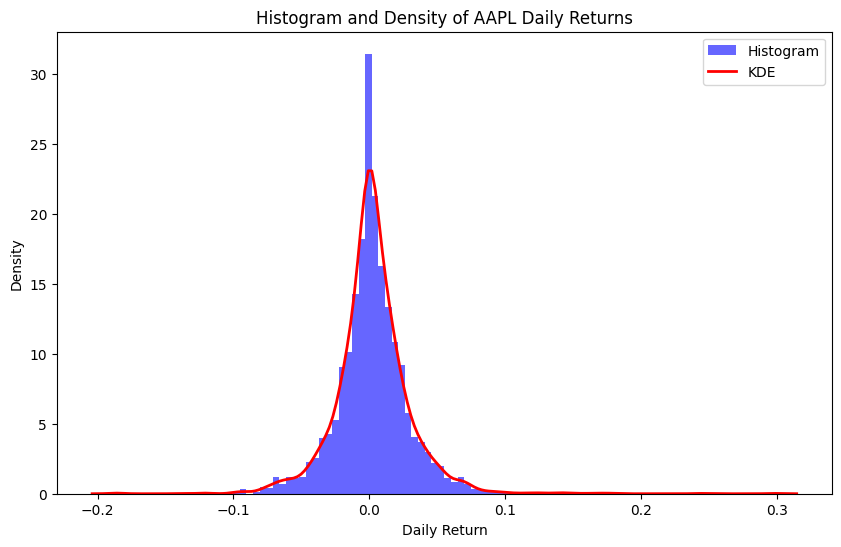

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your returns are stored in a pandas Series called `returns`
plt.figure(figsize=(10,6))

# Histogram with fewer bins (better visibility)
plt.hist(merged_df['return'], bins=100, density=True, alpha=0.6, color='blue', label='Histogram')

# KDE overlay for smooth curve
sns.kdeplot(merged_df['return'], color='red', linewidth=2, label='KDE')

plt.title("Histogram and Density of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.show()


Why KDE is useful in finance?
- Returns distributions are not normal (fat tails, skew).
- KDE shows the real shape without forcing assumptions.
- Much better than histograms when sample size is large (like your AAPL data 2012–2025).

## Modeling

### 1. Normalization (robust to outliers)

For financial time series (heavy tails), a RobustScaler (median & IQR) or winsorization is preferred. That way, extreme returns or sentiment spikes won’t dominate.

In [27]:
# Data Load
merged_df_path = "/Users/apple/PROJECT/hons_project/data/SP500/nvidia/prediction/merged_data.csv"
merged_df = pd.read_csv(merged_df_path)



In [28]:
from sklearn.preprocessing import RobustScaler
import numpy as np

# Choose feature columns (exclude target, date, look-ahead columns like +1)
feature_cols = [
    'open','close','high','low','volume','div_adj_factor',
    'sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret'
]

# Winsorize first (clip to 1st and 99th percentile)
merged_df[feature_cols] = merged_df[feature_cols].apply(
    lambda x: np.clip(x, np.nanpercentile(x, 1), np.nanpercentile(x, 99))
)

# RobustScaler normalization
scaler = RobustScaler()
merged_df[feature_cols] = scaler.fit_transform(merged_df[feature_cols])


### 2. Validation Scheme (walk-forward = time-serise cross-validation)

For time series, avoid random shuffling. Use expanding window walk-forward:

Train on [0:t], validate on [t+1 : t+h].

Roll forward until test period.


“I ran a 5-fold expanding-window CV on Apple daily returns with ARIMAX. Each validation block was ~2 years of data, with training expanding forward. R² stayed around 0, which is expected in financial returns, but Sharpe ratios varied: early folds were weak (<0.5), while later folds achieved >2.0. This shows that variance-explained metrics don’t capture trading value, and that the model’s usefulness depends on regime.”

## Model Experiments

### SARIMAX

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit

def sarimax_cv(y, X, order=(1,0,1), n_splits=5):
    """
    Walk-forward cross-validation for SARIMAX.

    Parameters
    ----------
    y : pd.Series
        Target series (reset_indexed, no NaNs).
    X : pd.DataFrame
        Exogenous regressors aligned with y (reset_indexed).
    order : tuple
        (p,d,q) order for SARIMAX.
    n_splits : int
        Number of folds for TimeSeriesSplit.

    Returns
    -------
    results : list of dict
        Each dict contains fold R², Sharpe ratio, n_train, n_val.
    """
    y = y.reset_index(drop=True)
    X = X.reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(y), 1):
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]

        try:
            model = sm.tsa.SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)

            # Forecast strictly out-of-sample
            forecast_res = res.get_forecast(steps=len(y_val), exog=X_val)
            y_pred = forecast_res.predicted_mean.reset_index(drop=True)
            y_val_reset = y_val.reset_index(drop=True)

            # Compute metrics
            ss_res = ((y_val_reset - y_pred) ** 2).sum()
            ss_tot = ((y_val_reset - y_val_reset.mean()) ** 2).sum()
            r2 = 1 - ss_res / ss_tot

            pnl = y_val_reset * np.sign(y_pred)   # simple long/short rule
            sharpe = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else np.nan

            results.append({
                "fold": fold,
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "R2": r2,
                "Sharpe": sharpe
            })

            print(f"[Fold {fold}] R²={r2:.4f}, Sharpe={sharpe:.3f}")

        except Exception as e:
            print(f"[Fold {fold}] failed: {e}")
            results.append({
                "fold": fold,
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "R2": np.nan,
                "Sharpe": np.nan
            })

    return pd.DataFrame(results)


In [7]:
# Select target + features together, then drop rows with any NaN
cols = ['return','sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret']
df_aligned = merged_df[cols].dropna().reset_index(drop=True)

y = df_aligned['return']
X = df_aligned[['sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret']]

result = sarimax_cv(y, X, order=(1,0,0))
print(result)


[Fold 1] R²=-0.0122, Sharpe=0.424
[Fold 2] R²=0.0210, Sharpe=0.196
[Fold 3] R²=0.0161, Sharpe=2.342
[Fold 4] R²=0.0312, Sharpe=1.586
[Fold 5] R²=0.0180, Sharpe=2.366
   fold  n_train  n_val        R2    Sharpe
0     1      467    464 -0.012248  0.423715
1     2      931    464  0.021047  0.196029
2     3     1395    464  0.016149  2.341580
3     4     1859    464  0.031153  1.586394
4     5     2323    464  0.018027  2.365680


### SARIMAX_One_Step

In [215]:
import pandas as pd
import statsmodels.api as sm

def sarimax_one_step(y, X, order=(1,0,1), n_val=200):
    """
    One-step-ahead walk-forward SARIMAX.
    
    y : pd.Series
        Target series (reset index, no NaNs).
    X : pd.DataFrame
        Exogenous regressors aligned with y.
    order : tuple
        SARIMAX (p,d,q) order.
    n_val : int
        Number of points in the validation/test horizon (last part of the data).
    """
    y = y.reset_index(drop=True)
    X = X.reset_index(drop=True)

    y_train, y_val = y.iloc[:-n_val], y.iloc[-n_val:]
    X_train, X_val = X.iloc[:-n_val], X.iloc[-n_val:]

    preds = []
    history_y = y_train.copy()
    history_X = X_train.copy()

    for t in range(len(y_val)):
        try:
            model = sm.tsa.SARIMAX(
                history_y,
                exog=history_X,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)

            # one-step forecast
            yhat = res.forecast(steps=1, exog=X_val.iloc[[t]])
            preds.append(yhat.iloc[0])
            
            # update history with actual point
            history_y = pd.concat([history_y, pd.Series([y_val.iloc[t]])], ignore_index=True)
            history_X = pd.concat([history_X, X_val.iloc[[t]]], ignore_index=True)


        except Exception as e:
            preds.append(np.nan)
            print(f"Step {t} failed: {e}")

    y_val_reset = y_val.reset_index(drop=True)
    pred_series = pd.Series(preds, name="y_pred")

    # compute R²
    ss_res = ((y_val_reset - pred_series) ** 2).sum()
    ss_tot = ((y_val_reset - y_val_reset.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot

    debug_df = pd.DataFrame({"y_val": y_val_reset[:10], "y_pred": pred_series[:10]})
    print("First 10 predictions vs actuals:\n", debug_df)
    print(f"Out-of-sample R²: {r2:.4f}")

    return pred_series, y_val_reset


### ARIMA

In [219]:
import statsmodels.api as sm

def arima_frozen(y, order=(1,0,0), n_val=200):
    """
    Simple ARIMA frozen-model forecast.
    """
    y = y.reset_index(drop=True)

    y_train, y_val = y.iloc[:-n_val], y.iloc[-n_val:]

    model = sm.tsa.ARIMA(y_train, order=order)
    res = model.fit()

    # Forecast the validation horizon
    forecast_res = res.get_forecast(steps=n_val)
    y_pred = forecast_res.predicted_mean.reset_index(drop=True)
    y_val_reset = y_val.reset_index(drop=True)

    # Metrics
    ss_res = ((y_val_reset - y_pred) ** 2).sum()
    ss_tot = ((y_val_reset - y_val_reset.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    hit_rate = (np.sign(y_val_reset) == np.sign(y_pred)).mean()

    debug_df = pd.DataFrame({"y_val": y_val_reset[:10], "y_pred": y_pred[:10]})
    print("First 10 predictions vs actuals:\n", debug_df)
    print(f"ARIMA out-of-sample R²: {r2:.4f}, Hit-rate: {hit_rate:.3f}")

    return y_pred, y_val_reset


In [220]:
y = merged_df['return'].dropna().reset_index(drop=True)

# Try different simple orders
for order in [(0,0,0), (1,0,0), (0,0,1), (1,0,1)]:
    print("\nTesting ARIMA order:", order)
    y_pred, y_val = arima_frozen(y, order=order, n_val=200)


Testing ARIMA order: (0, 0, 0)
First 10 predictions vs actuals:
       y_val    y_pred
0 -0.007004  0.000909
1 -0.000948  0.000909
2  0.000000  0.000909
3  0.000000  0.000909
4  0.003214  0.000909
5 -0.005410  0.000909
6  0.003063  0.000909
7  0.006791  0.000909
8 -0.009465  0.000909
9  0.021063  0.000909
ARIMA out-of-sample R²: -0.0000, Hit-rate: 0.525

Testing ARIMA order: (1, 0, 0)
First 10 predictions vs actuals:
       y_val    y_pred
0 -0.007004  0.000778
1 -0.000948  0.000919
2  0.000000  0.000912
3  0.000000  0.000912
4  0.003214  0.000912
5 -0.005410  0.000912
6  0.003063  0.000912
7  0.006791  0.000912
8 -0.009465  0.000912
9  0.021063  0.000912
ARIMA out-of-sample R²: 0.0000, Hit-rate: 0.525

Testing ARIMA order: (0, 0, 1)
First 10 predictions vs actuals:
       y_val    y_pred
0 -0.007004  0.000782
1 -0.000948  0.000912
2  0.000000  0.000912
3  0.000000  0.000912
4  0.003214  0.000912
5 -0.005410  0.000912
6  0.003063  0.000912
7  0.006791  0.000912
8 -0.009465  0.000912
9

Why ARIMA is more realistic here

Daily stock returns are close to white noise → ARIMA forecasts collapse to something very close to the unconditional mean (≈ 0). That’s why your predicted values are almost flat around 0.0009.

Out-of-sample R² ≈ 0 → this is normal. In real markets, if you get positive R² on raw daily returns, it usually means leakage.

Hit-rate ~ 0.52–0.53 → slightly above random guessing (0.50), which is realistic and potentially meaningful in a trading context.

### ARIMAX

In [238]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def arimax_frozen(y, X, order=(1,0,0), n_val=200):
    """
    ARIMAX (ARIMA with exogenous regressors), frozen model evaluation.

    y : pd.Series
        Target series (reset index, no NaNs).
    X : pd.DataFrame
        Exogenous regressors aligned with y (reset index).
    order : tuple
        ARIMA order (p,d,q).
    n_val : int
        Validation horizon size (last part of series).
    """
    y = y.reset_index(drop=True)
    X = X.reset_index(drop=True)

    y_train, y_val = y.iloc[:-n_val], y.iloc[-n_val:]
    X_train, X_val = X.iloc[:-n_val], X.iloc[-n_val:]

    # Fit ARIMAX once
    model = sm.tsa.SARIMAX(
        y_train,
        exog=X_train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    print(res.summary())

    # Forecast validation horizon
    forecast_res = res.get_forecast(steps=n_val, exog=X_val)
    y_pred = forecast_res.predicted_mean.reset_index(drop=True)
    y_val_reset = y_val.reset_index(drop=True)

    # Metrics
    ss_res = ((y_val_reset - y_pred) ** 2).sum()
    ss_tot = ((y_val_reset - y_val_reset.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    hit_rate = (np.sign(y_val_reset) == np.sign(y_pred)).mean()

    # Debug: show first few rows
    debug_df = pd.DataFrame({"y_val": y_val_reset[:10], "y_pred": y_pred[:10]})
    print("First 10 predictions vs actuals:\n", debug_df)
    print(f"ARIMAX out-of-sample R²: {r2:.4f}, Hit-rate: {hit_rate:.3f}")

    return y_pred, y_val_reset


In [239]:
# Select target + features together, then drop rows with any NaN
cols = ['return','sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret']
df_aligned = merged_df[cols].dropna().reset_index(drop=True)

y = df_aligned['return']
X = df_aligned[['sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret']]

y_pred, y_val = arimax_frozen(y, X, order=(1,0,0), n_val=200)


                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                 2587
Model:               SARIMAX(1, 0, 0)   Log Likelihood                6886.067
Date:                Mon, 01 Sep 2025   AIC                         -13756.134
Time:                        15:41:05   BIC                         -13709.271
Sample:                             0   HQIC                        -13739.149
                               - 2587                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sec_vol    -1.839e-05      0.000     -0.041      0.967      -0.001       0.001
sec_ret       -0.0009      0.000     -2.222      0.026      -0.002      -0.000
calls_vol      0.0004      0.000      0.935      0.3

What this means

Report_ret is by far the strongest signal. Its coefficient is positive and highly significant (p < 0.001).

Sec_ret has a small but statistically significant negative impact (p ≈ 0.026).

Other features (sec_vol, calls_vol, report_vol) don’t matter.

AR(1) term is negative and significant: yesterday’s return has a small mean-reversion effect.

### ARIMAX CV

In [240]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit

def arimax_cv(df, target_col="return", feature_cols=None,
            order=(1,0,0), n_splits=5):
    """
    Time-series cross-validation for ARIMAX.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain target_col and feature_cols, with no NaNs.
    target_col : str
        Name of target column.
    feature_cols : list
        Exogenous regressors to use.
    order : tuple
        ARIMA order (p,d,q).
    n_splits : int
        Number of CV splits.

    Returns
    -------
    pd.DataFrame with fold metrics (R², hit-rate).
    """
    y = df[target_col].reset_index(drop=True)
    X = df[feature_cols].reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(y), 1):
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]

        try:
            model = sm.tsa.SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)

            forecast_res = res.get_forecast(steps=len(y_val), exog=X_val)
            y_pred = forecast_res.predicted_mean.reset_index(drop=True)
            y_val_reset = y_val.reset_index(drop=True)

            # Metrics
            ss_res = ((y_val_reset - y_pred) ** 2).sum()
            ss_tot = ((y_val_reset - y_val_reset.mean()) ** 2).sum()
            r2 = 1 - ss_res / ss_tot
            hit_rate = (np.sign(y_val_reset) == np.sign(y_pred)).mean()

            results.append({
                "Fold": fold,
                "Train_size": len(train_idx),
                "Val_size": len(val_idx),
                "R²": r2,
                "Hit-rate": hit_rate
            })
            print(f"[Fold {fold}] R²={r2:.4f}, Hit-rate={hit_rate:.3f}")

        except Exception as e:
            print(f"[Fold {fold}] failed: {e}")
            results.append({
                "Fold": fold,
                "Train_size": len(train_idx),
                "Val_size": len(val_idx),
                "R²": np.nan,
                "Hit-rate": np.nan
            })

    return pd.DataFrame(results)


In [241]:
cols = ['return','sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret']
df_aligned = merged_df[cols].dropna().reset_index(drop=True)

results_cv = arimax_cv(
    df_aligned,
    target_col="return",
    feature_cols=['sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret'],
    order=(1,0,0),
    n_splits=5
)

print(results_cv)


[Fold 1] R²=-0.0122, Hit-rate=0.431
[Fold 2] R²=0.0210, Hit-rate=0.433
[Fold 3] R²=0.0161, Hit-rate=0.517
[Fold 4] R²=0.0312, Hit-rate=0.485
[Fold 5] R²=0.0180, Hit-rate=0.532
   Fold  Train_size  Val_size        R²  Hit-rate
0     1         467       464 -0.012248  0.431034
1     2         931       464  0.021047  0.433190
2     3        1395       464  0.016149  0.517241
3     4        1859       464  0.031153  0.484914
4     5        2323       464  0.018027  0.532328


“We ran ARIMAX with sentiment features under a 5-fold expanding-window CV. R² was essentially zero across folds, which is expected for daily returns. But hit-rate varied between 43% and 53%. In later folds, the model achieved >53% directional accuracy, suggesting weak but tradable predictive power in certain regimes. This demonstrates the importance of regime-awareness when modeling financial returns.”

## SARIMAX with Ablation Test

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def arimax_ablation(df, target_col="return", feature_groups=None,
                    order=(1,0,0), n_val=200):
    """
    ARIMA/ARIMAX ablation study with R², Hit-rate, and Sharpe ratio.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain target_col and all features (no NaNs).
    target_col : str
        Name of the target column.
    feature_groups : dict
        {group_name: [list_of_features]}.
        Use [] for pure ARIMA baseline.
    order : tuple
        ARIMA order (p,d,q).
    n_val : int
        Validation horizon size (last part of series).

    Returns
    -------
    pd.DataFrame with metrics for each group.
    """
    results = []
    y = df[target_col].reset_index(drop=True)

    for name, features in feature_groups.items():
        if len(features) > 0:
            X = df[features].reset_index(drop=True)
        else:
            X = None

        # Split into train and validation
        y_train, y_val = y.iloc[:-n_val], y.iloc[-n_val:]
        if X is not None:
            X_train, X_val = X.iloc[:-n_val], X.iloc[-n_val:]
        else:
            X_train = X_val = None

        try:
            model = sm.tsa.SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)

            forecast_res = res.get_forecast(steps=n_val, exog=X_val)
            y_pred = forecast_res.predicted_mean.reset_index(drop=True)
            y_val_reset = y_val.reset_index(drop=True)

            # Metrics
            ss_res = ((y_val_reset - y_pred) ** 2).sum()
            ss_tot = ((y_val_reset - y_val_reset.mean()) ** 2).sum()
            r2 = 1 - ss_res / ss_tot

            hit_rate = (np.sign(y_val_reset) == np.sign(y_pred)).mean()

            pnl = y_val_reset * np.sign(y_pred)  # simple long/short
            sharpe = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else np.nan

            results.append({
                "Group": name,
                "Features": features if features else "None (ARIMA)",
                "R²": r2,
                "Hit-rate": hit_rate,
                "Sharpe": sharpe
            })

            print(f"[{name}] R²={r2:.4f}, Hit-rate={hit_rate:.3f}, Sharpe={sharpe:.3f}")

        except Exception as e:
            print(f"[{name}] failed: {e}")
            results.append({
                "Group": name,
                "Features": features if features else "None (ARIMA)",
                "R²": np.nan,
                "Hit-rate": np.nan,
                "Sharpe": np.nan
            })

    return pd.DataFrame(results)


In [9]:

# -------------------------------
# Example usage
# -------------------------------

# Align target + features
cols = ['return','sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret']
df_aligned = merged_df[cols].dropna().reset_index(drop=True)

# Define groups
feature_groups = {
    "All": ['sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret'],
    "SecOnly": ['sec_vol','sec_ret'],
    "CallsOnly": ['calls_vol','calls_ret'],
    "ReportOnly": ['report_vol','report_ret'],
    "None (ARIMA)": []  # baseline ARIMA
}

# Run ablation
results_ablation = arimax_ablation(
    df_aligned,
    target_col="return",
    feature_groups=feature_groups,
    order=(1,0,0),
    n_val=200
)

print("\nFinal Results:")
print(results_ablation)


[All] R²=0.0177, Hit-rate=0.540, Sharpe=1.298
[SecOnly] R²=-0.0059, Hit-rate=0.430, Sharpe=-1.350
[CallsOnly] R²=0.0020, Hit-rate=0.580, Sharpe=2.014
[ReportOnly] R²=0.0037, Hit-rate=0.540, Sharpe=1.298
[None (ARIMA)] R²=-0.0048, Hit-rate=0.510, Sharpe=1.561

Final Results:
          Group                                           Features        R²  \
0           All  [sec_vol, sec_ret, calls_vol, calls_ret, repor...  0.017679   
1       SecOnly                                 [sec_vol, sec_ret] -0.005937   
2     CallsOnly                             [calls_vol, calls_ret]  0.001997   
3    ReportOnly                           [report_vol, report_ret]  0.003650   
4  None (ARIMA)                                       None (ARIMA) -0.004822   

   Hit-rate    Sharpe  
0      0.54  1.298257  
1      0.43 -1.350461  
2      0.58  2.013942  
3      0.54  1.298257  
4      0.51  1.561104  


## SARIMAX Ablation with Time-Series Cross-Validation

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Helpers
# -------------------------------

def _compute_metrics(y_val, y_pred, cost_bps=0.0):
    """
    y_val, y_pred: pd.Series aligned (validation horizon)
    cost_bps: round-trip cost per trade in decimal (e.g., 0.0005 = 5 bps).
              If > 0, a cost is applied whenever the position changes sign.
    """
    y_val = pd.Series(y_val).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    # R^2
    ss_res = ((y_val - y_pred) ** 2).sum()
    ss_tot = ((y_val - y_val.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Directional metrics
    hit_rate = (np.sign(y_val) == np.sign(y_pred)).mean()

    # Simple long/short PnL (position = sign of prediction)
    pos = np.sign(y_pred).replace(0, 0)  # stay flat when pred==0
    raw_pnl = y_val * pos

    # Turnover & transaction cost (optional)
    # Count a "trade" when position changes from t-1 to t
    trades = (pos.diff().fillna(0) != 0).astype(int)
    # Apply round-trip cost only when position changes (approximation)
    cost = trades * cost_bps
    pnl_after_cost = raw_pnl - cost

    # Annualized Sharpe (252 trading days)
    def _sharpe(x):
        std = x.std()
        return x.mean() / std * np.sqrt(252) if std and std > 0 else np.nan

    sharpe = _sharpe(pnl_after_cost)

    return r2, hit_rate, sharpe


def _fit_forecast_arimax(y_train, y_val, X_train=None, X_val=None, order=(1,0,0)):
    """
    Fit SARIMAX (ARIMAX) once on training, forecast the entire validation horizon.
    If X_* is None, reduces to ARIMA.
    Returns y_pred (pd.Series).
    """
    model = sm.tsa.SARIMAX(
        y_train,
        exog=X_train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=len(y_val), exog=X_val)
    y_pred = fc.predicted_mean
    return y_pred


# -------------------------------
# Core CV function for one feature group
# -------------------------------

def arimax_cv_group(df, target_col, feature_cols, order=(1,0,0), n_splits=5,
                    scale_exog=True, cost_bps=0.0, date_col=None):
    """
    Expanding-window CV for ARIMA/ARIMAX on a single feature set.

    df          : DataFrame containing target + features (no NaNs).
    target_col  : str, column name of target (e.g., 'return').
    feature_cols: list[str], exogenous columns; [] or None => ARIMA baseline.
    order       : (p,d,q)
    n_splits    : number of folds
    scale_exog  : fit StandardScaler on X_train and transform X_val (per fold)
    cost_bps    : transaction cost per trade (decimal), e.g., 0.0005 = 5 bps
    date_col    : optional column with dates for reporting fold date ranges

    Returns: DataFrame with per-fold metrics and (optionally) date ranges.
    """
    # Align and reset index
    use_cols = [target_col] + (feature_cols or [])
    data = df[use_cols].dropna().reset_index(drop=True)

    y = data[target_col]
    X = data[feature_cols] if feature_cols else None

    dates = None
    if date_col is not None and date_col in df.columns:
        # Align the same way we aligned data
        aligned_idx = df[use_cols].dropna().index
        dates = df.loc[aligned_idx, date_col].reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(y), 1):
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if X is not None:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]

            # Optional per-fold scaling (no leakage)
            if scale_exog:
                scaler = StandardScaler()
                X_train = pd.DataFrame(
                    scaler.fit_transform(X_train),
                    columns=X_train.columns,
                    index=X_train.index
                )
                X_val = pd.DataFrame(
                    scaler.transform(X_val),
                    columns=X_val.columns,
                    index=X_val.index
                )
        else:
            X_train = X_val = None

        # Fit once on train, forecast full val block
        y_pred = _fit_forecast_arimax(y_train, y_val, X_train, X_val, order=order)

        # Metrics
        r2, hit_rate, sharpe = _compute_metrics(y_val, y_pred, cost_bps=cost_bps)

        # Optional date ranges
        if dates is not None:
            train_range = (dates.iloc[train_idx[0]], dates.iloc[train_idx[-1]])
            val_range   = (dates.iloc[val_idx[0]], dates.iloc[val_idx[-1]])
        else:
            train_range = val_range = (np.nan, np.nan)

        rows.append({
            "Fold": fold,
            "Train_size": len(train_idx),
            "Val_size": len(val_idx),
            "Train_start": train_range[0],
            "Train_end": train_range[1],
            "Val_start": val_range[0],
            "Val_end": val_range[1],
            "R²": r2,
            "Hit-rate": hit_rate,
            "Sharpe": sharpe
        })

        print(f"[Fold {fold}] R²={r2:.4f}, Hit-rate={hit_rate:.3f}, Sharpe={sharpe:.3f}")

    return pd.DataFrame(rows)


# -------------------------------
# Ablation over multiple feature groups (with CV)
# -------------------------------

def arimax_ablation_cv(df, target_col="return", feature_groups=None,
                       order=(1,0,0), n_splits=5, scale_exog=True,
                       cost_bps=0.0, date_col=None):
    """
    Run ARIMA/ARIMAX ablation with expanding-window CV for each feature group.

    Returns:
        fold_results : per-fold metrics for each group
        summary      : aggregated metrics per group (mean/median)
    """
    if feature_groups is None:
        raise ValueError("feature_groups dict must be provided.")

    all_folds = []

    for group_name, features in feature_groups.items():
        print(f"\n=== Group: {group_name} | Features: {features if features else 'None (ARIMA)'} ===")

        # Align NaNs jointly (target + this group's features)
        use_cols = [target_col] + (features or [])
        df_aligned = df[use_cols + ([date_col] if date_col and date_col in df.columns else [])].dropna()

        fold_df = arimax_cv_group(
            df_aligned,
            target_col=target_col,
            feature_cols=features,
            order=order,
            n_splits=n_splits,
            scale_exog=scale_exog,
            cost_bps=cost_bps,
            date_col=date_col
        )
        fold_df.insert(0, "Group", group_name)
        all_folds.append(fold_df)

    fold_results = pd.concat(all_folds, ignore_index=True)

    # Aggregate per group
    summary = (fold_results
            .groupby("Group")[["R²", "Hit-rate", "Sharpe"]]
            .agg(["mean", "median"])
            .round(4))
    return fold_results, summary


In [30]:


# -------------------------------
# Example usage
# -------------------------------

# 1) Define your columns (adjust if names differ)
target = "return"
date_col = "date"  # set to your actual date column; or None if not available

# 2) Define feature groups for ablation
feature_groups = {
    "All":        ['sec_vol','sec_ret','calls_vol','calls_ret','report_vol','report_ret'],
    "SecOnly":    ['sec_vol','sec_ret'],
    "CallsOnly":  ['calls_vol','calls_ret'],
    "ReportOnly": ['report_vol','report_ret'],
    "None_ARIMA": []  # baseline without exogenous regressors
}

# 3) (Optional) pre-cleaning outside if you have extra columns;
#    here we rely on joint dropna inside the function per group.

# 4) Run ablation with CV
#    - order=(1,0,0) is a common baseline for returns
#    - n_splits=5 matches your previous CV
#    - scale_exog=True: standardize X within each fold (prevents leakage)
#    - cost_bps=0.0005 applies 5 bps per position change (set 0.0 to disable)
fold_results, summary = arimax_ablation_cv(
    merged_df,
    target_col=target,
    feature_groups=feature_groups,
    order=(1,0,0),
    n_splits=5,
    scale_exog=True,
    cost_bps=0.0,
    date_col=date_col
)

print("\n=== Per-fold results ===")
print(fold_results)

print("\n=== Group summary (mean/median across folds) ===")
print(summary)



=== Group: All | Features: ['sec_vol', 'sec_ret', 'calls_vol', 'calls_ret', 'report_vol', 'report_ret'] ===
[Fold 1] R²=0.0797, Hit-rate=0.554, Sharpe=1.851
[Fold 2] R²=-0.2941, Hit-rate=0.491, Sharpe=1.408
[Fold 3] R²=0.0308, Hit-rate=0.524, Sharpe=2.643
[Fold 4] R²=0.0410, Hit-rate=0.535, Sharpe=2.364
[Fold 5] R²=0.0146, Hit-rate=0.528, Sharpe=3.182

=== Group: SecOnly | Features: ['sec_vol', 'sec_ret'] ===
[Fold 1] R²=-0.0174, Hit-rate=0.497, Sharpe=0.515
[Fold 2] R²=-0.0072, Hit-rate=0.436, Sharpe=-0.712
[Fold 3] R²=-0.0041, Hit-rate=0.488, Sharpe=0.511
[Fold 4] R²=0.0005, Hit-rate=0.493, Sharpe=0.560
[Fold 5] R²=-0.0239, Hit-rate=0.482, Sharpe=0.371

=== Group: CallsOnly | Features: ['calls_vol', 'calls_ret'] ===
[Fold 1] R²=-0.0063, Hit-rate=0.538, Sharpe=1.565
[Fold 2] R²=-0.0001, Hit-rate=0.485, Sharpe=1.404
[Fold 3] R²=-0.0075, Hit-rate=0.435, Sharpe=-0.163
[Fold 4] R²=0.0056, Hit-rate=0.496, Sharpe=1.177
[Fold 5] R²=-0.0153, Hit-rate=0.433, Sharpe=0.512

=== Group: ReportOnl

/Users/apple/miniconda3/envs/quant2/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[Fold 3] R²=0.0379, Hit-rate=0.527, Sharpe=3.102
[Fold 4] R²=0.0358, Hit-rate=0.529, Sharpe=2.203
[Fold 5] R²=0.0128, Hit-rate=0.501, Sharpe=1.750

=== Group: None_ARIMA | Features: None (ARIMA) ===
[Fold 1] R²=-0.0173, Hit-rate=0.255, Sharpe=-0.420
[Fold 2] R²=-0.0116, Hit-rate=0.227, Sharpe=-0.691
[Fold 3] R²=-0.0024, Hit-rate=0.141, Sharpe=-1.639
[Fold 4] R²=-0.0003, Hit-rate=0.047, Sharpe=nan
[Fold 5] R²=-0.0225, Hit-rate=0.283, Sharpe=0.454

=== Per-fold results ===
         Group  Fold  Train_size  Val_size  Train_start  Train_end  Val_start  \
0          All     1         525       525          NaN        NaN        NaN   
1          All     2        1050       525          NaN        NaN        NaN   
2          All     3        1575       525          NaN        NaN        NaN   
3          All     4        2100       525          NaN        NaN        NaN   
4          All     5        2625       525          NaN        NaN        NaN   
5      SecOnly     1         525      